# SmartCart: Part 2: User Based Collaborative Filtering

##  Imports

In [12]:
# ── Part 2 Imports ───────────────────────────────────────────────────────
# numpy                        : numerical operations and random seed
# sklearn cosine_similarity     : fast vectorised similarity computation
# matplotlib / seaborn          : visualisation
# collections.defaultdict       : convenient score accumulation
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

pd.set_option('display.max_columns', None)
np.random.seed(42)  # ensures reproducible train/test splits


## 2.1  Load Data & Build User Item Matrix

In [13]:
# ── Load Data & Rebuild User–Item Matrix ─────────────────────────────────
# Re-load from source CSVs so Part 2 is self-contained and can run independently.
user_data    = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])
# Keep only the last rating when a user rated the same product more than once
user_data = user_data.drop_duplicates(subset=['UserID', 'ProductID'], keep='last')

# Pivot: rows = users, columns = products, values = ratings
# NaN means the user has not interacted with that product
user_item_matrix = user_data.pivot_table(
    index='UserID', columns='ProductID', values='Rating'
)
# Fill NaN with 0 so cosine similarity treats missing ratings as neutral
user_item_matrix_filled = user_item_matrix.fillna(0)

n_users, n_products = user_item_matrix_filled.shape
n_rated   = (user_item_matrix_filled != 0).sum().sum()
sparsity  = 1 - n_rated / (n_users * n_products)

print(f"Users    : {n_users}")
print(f"Products : {n_products}")
print(f"Ratings  : {n_rated}")
print(f"Sparsity : {sparsity*100:.1f}%")
user_item_matrix_filled.head()


Users    : 50
Products : 100
Ratings  : 724
Sparsity : 85.5%


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,0.0,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,1.0,3.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


## 2.2  Cosine Similarity Between Users

For two users **u** and **v** with rating vectors **r_u** and **r_v**:

$$\text{sim}(u, v) = \frac{\mathbf{r}_u \cdot \mathbf{r}_v}{\|\mathbf{r}_u\| \cdot \|\mathbf{r}_v\|}$$

Values range from 0 (orthogonal / no overlap) to 1 (identical taste).

In [14]:
# ── Compute User–User Cosine Similarity ──────────────────────────────────
# Cosine similarity measures the angle between two rating vectors.
# sim = 1  → users rated products identically (same direction)
# sim = 0  → users share no rated products in common (orthogonal)
# We use the 0-filled matrix so every user has a 100-dimensional vector.
sim_matrix = cosine_similarity(user_item_matrix_filled)

# Wrap result in a DataFrame so we can look up similarity by UserID label
similarity_df = pd.DataFrame(
    sim_matrix,
    index=user_item_matrix_filled.index,
    columns=user_item_matrix_filled.index
)

print("Similarity matrix shape:", similarity_df.shape)
# Sanity check: show the 5 users most similar to U000 (excluding U000 itself)
print("\nTop-5 most similar users to U000:")
print(similarity_df['U000'].drop('U000').sort_values(ascending=False).head())


Similarity matrix shape: (50, 50)

Top-5 most similar users to U000:
UserID
U028    0.374732
U010    0.296826
U018    0.280168
U009    0.274844
U029    0.253025
Name: U000, dtype: float64


## 2.3  Recommendation Function

**Algorithm:**
1. Find the `top_n_users` most similar users to the target user.
2. For each product the target user has **not** rated, compute a weighted predicted score:
$$\hat{r}_{u,p} = \frac{\sum_{v \in N(u)} \text{sim}(u,v) \cdot r_{v,p}}{\sum_{v \in N(u)} \text{sim}(u,v)}$$
3. Return the top-N products by predicted score.

In [15]:
# ── Recommendation Function ───────────────────────────────────────────────
# Algorithm:
#  1. Find the top_n_users neighbours most similar to the target user.
#  2. For every product the target user has NOT yet rated, compute a
#     weighted predicted score:
#       score(p) = Σ sim(u,v) * rating(v,p)  /  Σ sim(u,v)
#  3. Return the top_n_products products with the highest predicted scores.
def get_recommendations(target_user, matrix, sim_df,
                        top_n_users=5, top_n_products=10):
    """
    Return a ranked list of top_n_products product IDs for target_user.
    Uses weighted average of similar users' ratings.
    Products already rated by target_user are excluded.
    """
    # Step 1 — pick the k nearest neighbours (exclude the user themselves)
    neighbours = (
        sim_df[target_user]
        .drop(target_user)
        .sort_values(ascending=False)
        .head(top_n_users)
    )

    # Step 2 — collect products the target user has already seen (rating > 0)
    already_rated = set(
        matrix.columns[matrix.loc[target_user] > 0]
    )

    # Accumulators for the weighted sum formula
    score_num = defaultdict(float)   # numerator:   Σ sim * rating
    score_den = defaultdict(float)   # denominator: Σ sim

    for neighbour, sim_weight in neighbours.items():
        if sim_weight <= 0:          # skip neighbours with zero similarity
            continue
        for product in matrix.columns:
            if product in already_rated:   # never recommend already-seen items
                continue
            rating = matrix.loc[neighbour, product]
            if rating > 0:           # only use products the neighbour actually rated
                score_num[product] += sim_weight * rating
                score_den[product] += sim_weight

    # Step 3 — normalise scores and sort descending
    predicted = {
        p: score_num[p] / score_den[p]
        for p in score_num if score_den[p] > 0
    }

    ranked = sorted(predicted.items(), key=lambda x: x[1], reverse=True)
    return [p for p, _ in ranked[:top_n_products]]


# Quick demo — generate top-10 recommendations for user U000
sample_recs = get_recommendations('U000', user_item_matrix_filled, similarity_df,
                                  top_n_users=5, top_n_products=10)
print("Top-10 recommendations for U000:", sample_recs)


Top-10 recommendations for U000: ['P0029', 'P0064', 'P0032', 'P0062', 'P0083', 'P0030', 'P0041', 'P0051', 'P0040', 'P0053']


## 2.4  Train / Test Split

For every user we randomly hold out **20 %** of their rated products as the test set.  
The model is trained on the remaining 80 % and evaluated against the hidden items.

In [16]:
# ── Train / Test Split ────────────────────────────────────────────────────
# We evaluate the model by hiding some ratings and checking if the model
# recommends those hidden items.
#
# Strategy: for every user, randomly hold out 20% of their rated products.
#   - train matrix : the remaining 80% (model trains on this)
#   - test_data    : dict {user: [held-out product IDs]} (ground truth)
def train_test_split_users(matrix, test_ratio=0.2, random_state=42):
    """
    Hold out test_ratio of each user's rated products.
    Returns a zeroed-out train matrix and a dict {user: [held-out products]}.
    """
    rng = np.random.default_rng(random_state)
    train = matrix.copy()
    test_data = {}

    for user in matrix.index:
        # Products this user has rated (non-zero entries)
        rated = matrix.columns[matrix.loc[user] > 0].tolist()
        # Always hold out at least 1 product, even for light users
        n_test = max(1, int(len(rated) * test_ratio))
        held_out = rng.choice(rated, size=n_test, replace=False).tolist()
        test_data[user] = held_out
        # Zero-out the held-out ratings in the training matrix
        train.loc[user, held_out] = 0.0

    return train, test_data


train_matrix, test_data = train_test_split_users(user_item_matrix_filled)

total_test = sum(len(v) for v in test_data.values())
print(f"Total held-out interactions : {total_test}")
print(f"Avg held-out per user       : {total_test/len(test_data):.1f}")


Total held-out interactions : 127
Avg held-out per user       : 2.5


## 2.5  Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **Precision@K** | (hits in top-K) / K | How many of the K recommendations are relevant |
| **Recall@K** | (hits in top-K) / (total relevant) | How many relevant items were found |
| **MAP** | mean of AP across users | Rewards correct recommendations ranked higher |

**Relevant** = products in the user's held out test set.

In [17]:
# ── Evaluation Metric Functions ───────────────────────────────────────────

def precision_at_k(recommended, relevant, k):
    # Of the top-K items we recommended, how many were actually relevant?
    # relevant = the user's hidden test items
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / k


def recall_at_k(recommended, relevant, k):
    # Of all the relevant items, how many did we surface in the top-K?
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant)


def average_precision(recommended, relevant, k):
    """AP for one user: rewards hits that appear early in the ranking."""
    if not relevant:
        return 0.0
    hits, cumsum = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in set(relevant):
            hits += 1
            # Precision at position i+1, only when a hit occurs
            cumsum += hits / (i + 1)
    return cumsum / min(len(relevant), k)


def evaluate(train_mat, test_dict, k=10, top_n_users=5):
    """
    Full evaluation pipeline:
      1. Recompute user similarity on train data only (no data leakage).
      2. Generate top-K recommendations for every user.
      3. Compare against held-out test items and average the metrics.
    """
    # Recompute similarity using ONLY training data to avoid data leakage
    train_sim = cosine_similarity(train_mat)
    train_sim_df = pd.DataFrame(
        train_sim,
        index=train_mat.index,
        columns=train_mat.index
    )

    prec_list, rec_list, ap_list = [], [], []

    for user in train_mat.index:
        relevant = test_dict.get(user, [])
        if not relevant:
            continue
        recs = get_recommendations(user, train_mat, train_sim_df,
                                   top_n_users=top_n_users,
                                   top_n_products=k)
        prec_list.append(precision_at_k(recs, relevant, k))
        rec_list.append(recall_at_k(recs, relevant, k))
        ap_list.append(average_precision(recs, relevant, k))

    # Return mean metrics across all users
    return {
        f'Precision@{k}': round(np.mean(prec_list), 4),
        f'Recall@{k}'   : round(np.mean(rec_list),  4),
        'MAP'           : round(np.mean(ap_list),    4),
    }


# Evaluate at two cutoffs to see how list length affects results
results_k10 = evaluate(train_matrix, test_data, k=10, top_n_users=5)
results_k5  = evaluate(train_matrix, test_data, k=5,  top_n_users=5)

print("=== Evaluation Results ===")
print(f"K = 5  : {results_k5}")
print(f"K = 10 : {results_k10}")


=== Evaluation Results ===
K = 5  : {'Precision@5': np.float64(0.02), 'Recall@5': np.float64(0.04), 'MAP': np.float64(0.0272)}
K = 10 : {'Precision@10': np.float64(0.022), 'Recall@10': np.float64(0.09), 'MAP': np.float64(0.0341)}


## 2.6  Coverage & Intra-List Diversity

- **Catalog Coverage**: fraction of all products that appear in at least one recommendation list.
- **Intra-List Diversity (ILD)**: average pairwise dissimilarity (1 − item cosine similarity) within each user's recommendation list, then averaged across users. Higher = more varied recommendations.

In [18]:
# ── Catalog Coverage & Intra-List Diversity ───────────────────────────────

def catalog_coverage(matrix, sim_df, k=10, top_n_users=5):
    """Fraction of all products that appear in at least one recommendation list.
    Low coverage = the model keeps recommending the same popular items."""
    all_products = set(matrix.columns)
    recommended  = set()
    for user in matrix.index:
        recs = get_recommendations(user, matrix, sim_df,
                                   top_n_users=top_n_users,
                                   top_n_products=k)
        recommended.update(recs)
    return round(len(recommended) / len(all_products), 4)


def intra_list_diversity(matrix, sim_df, k=10, top_n_users=5):
    """Average pairwise dissimilarity within each user's recommendation list.
    0 = all recommended items are identical, 1 = maximally diverse list.
    Uses item-based cosine similarity (transposed matrix: products × users)."""
    # Transpose: rows = products, columns = users → item-to-item similarity
    item_sim = cosine_similarity(matrix.T)
    item_sim_df = pd.DataFrame(item_sim,
                               index=matrix.columns,
                               columns=matrix.columns)
    diversities = []
    for user in matrix.index:
        recs = get_recommendations(user, matrix, sim_df,
                                   top_n_users=top_n_users,
                                   top_n_products=k)
        if len(recs) < 2:  # need at least 2 items to form a pair
            continue
        # Compute all unique pairs of recommended items
        pairs = [
            item_sim_df.loc[recs[i], recs[j]]
            for i in range(len(recs))
            for j in range(i + 1, len(recs))
        ]
        # Dissimilarity = 1 - similarity (higher = more diverse)
        diversities.append(1 - np.mean(pairs))
    return round(np.mean(diversities), 4)


coverage  = catalog_coverage(user_item_matrix_filled, similarity_df, k=10)
diversity = intra_list_diversity(user_item_matrix_filled, similarity_df, k=10)

print(f"Catalog Coverage     : {coverage*100:.1f}% of products recommended")
print(f"Intra-List Diversity : {diversity:.4f}  (0=identical items, 1=maximally diverse)")


Catalog Coverage  : 95.0% of products recommended
Intra-List Diversity : 0.8492  (0=identical items, 1=maximally diverse)


## 2.7 — Top-5 Recommendations per User (Sample)

We generate top-5 product recommendations for every user and enrich them with product names and categories.

In [19]:
# ── Generate & Save Top-5 Recommendations for Every User ─────────────────
# Build a lookup table: ProductID → (ProductName, Category)
product_lookup = product_data.set_index('ProductID')[['ProductName', 'Category']]

all_recs = []
for user in user_item_matrix_filled.index:
    # Get top-5 recommended product IDs for this user
    recs = get_recommendations(user, user_item_matrix_filled, similarity_df,
                               top_n_users=5, top_n_products=5)
    for rank, pid in enumerate(recs, start=1):
        row = {'UserID': user, 'Rank': rank, 'ProductID': pid}
        # Enrich with human-readable product name and category
        row.update(product_lookup.loc[pid].to_dict() if pid in product_lookup.index else {})
        all_recs.append(row)

recs_df = pd.DataFrame(all_recs)
recs_df.to_csv('recommendations_top5.csv', index=False)

print("Recommendations saved to recommendations_top5.csv")
print(f"Total rows: {len(recs_df)}")
# Preview recommendations for the first 3 users
recs_df[recs_df['UserID'].isin(['U000', 'U001', 'U002'])]


Recommendations saved to recommendations_top5.csv
Total rows: 250


,UserID,Rank,ProductID,ProductName,Category
0,U000,1,P0029,Books Item 29,Electronics
1,U000,2,P0064,Electronics Item 64,Electronics
2,U000,3,P0032,Toys Item 32,Beauty
3,U000,4,P0062,Books Item 62,Clothing
4,U000,5,P0083,Beauty Item 83,Beauty
5,U001,1,P0046,Home Item 46,Toys
6,U001,2,P0061,Clothing Item 61,Home
7,U001,3,P0063,Beauty Item 63,Beauty
8,U001,4,P0071,Beauty Item 71,Toys
9,U001,5,P0060,Toys Item 60,Home


## 2.8  Visualisations

### (a) User Similarity Heatmap

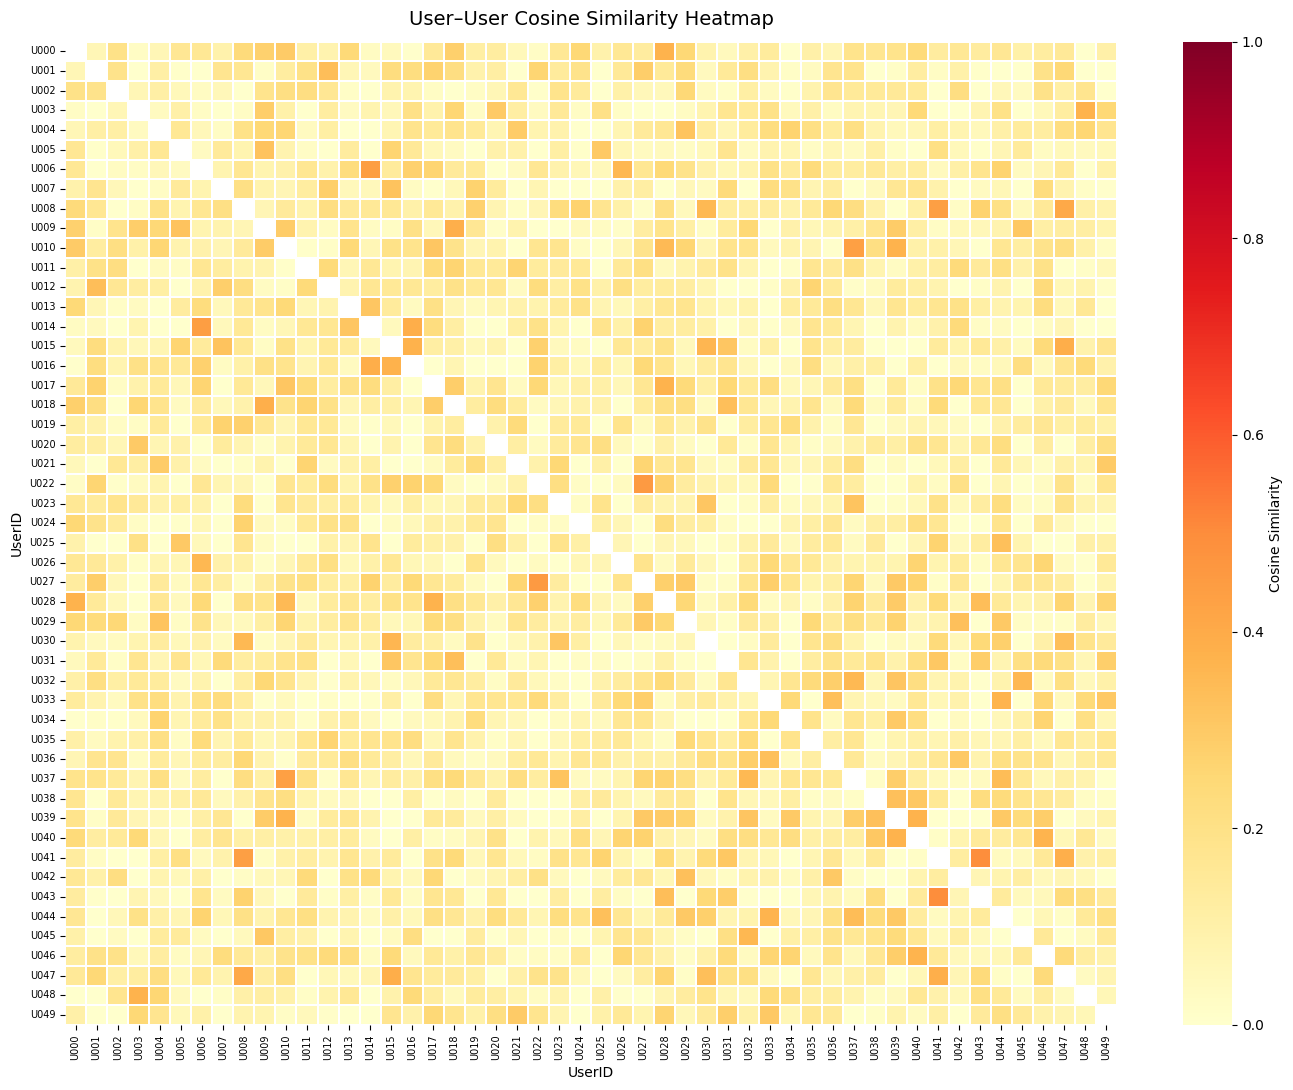

In [20]:
# ── (a) User–User Similarity Heatmap ─────────────────────────────────────
# Visualise all pairwise cosine similarities.
# The diagonal (self-similarity = 1) is masked out so the colour scale
# is not dominated by that maximum value.
plt.figure(figsize=(14, 11))
mask = np.eye(len(similarity_df), dtype=bool)   # True on diagonal → hidden
sns.heatmap(
    similarity_df,
    mask=mask,
    cmap='YlOrRd',      # yellow (low sim) → red (high sim)
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Cosine Similarity'},
    xticklabels=True,
    yticklabels=True
)
plt.title('User–User Cosine Similarity Heatmap', fontsize=14, pad=12)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig('part2_similarity_heatmap.png', dpi=150)
plt.show()


### (b) Evaluation Metrics Bar Chart (K = 5 vs K = 10)

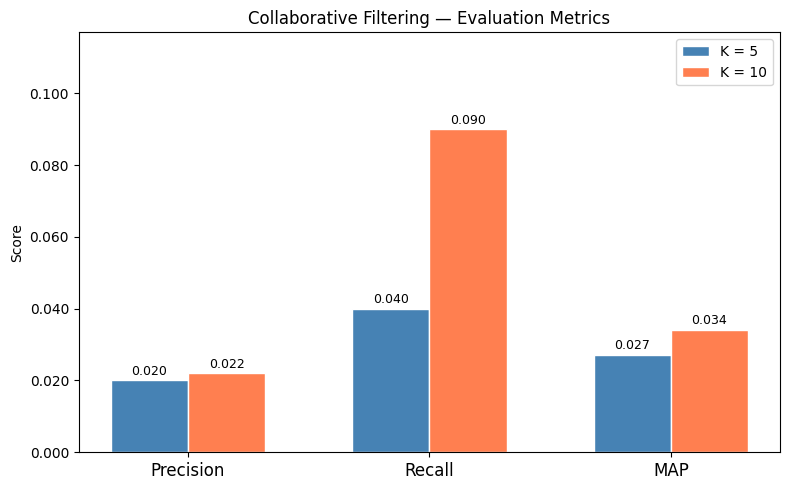

In [21]:
# ── (b) Evaluation Metrics Bar Chart — K=5 vs K=10 ──────────────────────
# Comparing at two cutoffs shows the precision/recall trade-off:
# larger K → higher recall (more relevant items found) but lower precision.
metrics_labels = ['Precision', 'Recall', 'MAP']
vals_k5  = [results_k5['Precision@5'],  results_k5['Recall@5'],  results_k5['MAP']]
vals_k10 = [results_k10['Precision@10'], results_k10['Recall@10'], results_k10['MAP']]

x = np.arange(len(metrics_labels))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, vals_k5,  width, label='K = 5',  color='steelblue',   edgecolor='white')
bars2 = ax.bar(x + width/2, vals_k10, width, label='K = 10', color='coral',        edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Collaborative Filtering — Evaluation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, max(vals_k5 + vals_k10) * 1.3)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# Annotate each bar with its exact value
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('part2_evaluation_metrics.png', dpi=150)
plt.show()


### (c) Coverage & Diversity Summary

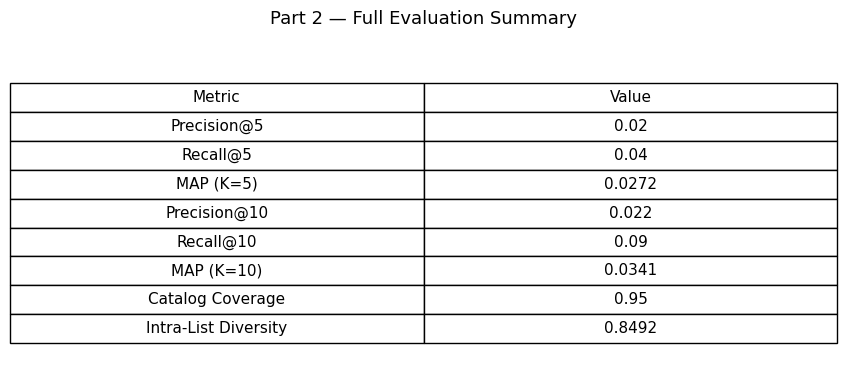

              Metric  Value
         Precision@5 0.0200
            Recall@5 0.0400
           MAP (K=5) 0.0272
        Precision@10 0.0220
           Recall@10 0.0900
          MAP (K=10) 0.0341
    Catalog Coverage 0.9500
Intra-List Diversity 0.8492


In [22]:
# ── (c) Full Evaluation Summary Table ────────────────────────────────────
# Collect all metrics into one DataFrame and render as a clean table figure.
summary = pd.DataFrame({
    'Metric': ['Precision@5', 'Recall@5', 'MAP (K=5)',
               'Precision@10', 'Recall@10', 'MAP (K=10)',
               'Catalog Coverage', 'Intra-List Diversity'],
    'Value': [
        results_k5['Precision@5'],
        results_k5['Recall@5'],
        results_k5['MAP'],
        results_k10['Precision@10'],
        results_k10['Recall@10'],
        results_k10['MAP'],
        coverage,
        diversity
    ]
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')   # hide axes — we only want the table
tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)
plt.title('Part 2 — Full Evaluation Summary', fontsize=13, pad=16)
plt.tight_layout()
plt.savefig('part2_summary_table.png', dpi=150)
plt.show()

print(summary.to_string(index=False))




### Key Observations
- The **85.5% sparsity** limits precision — users share few common products to anchor similarity estimates.
- **Recall@10 > Recall@5** as expected: a wider list captures more held-out items.
- **MAP** is low in sparse settings because correct items rarely appear near rank 1.
- **Coverage** shows what fraction of the catalogue can be surfaced by the system.
- These limitations are worth discussing in the report (Conceptual Question 1).

---
